<a href="https://colab.research.google.com/github/Trifebri3/UTSMLCitrus/blob/main/UTSMechinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import File data model

In [6]:
from google.colab import files
uploaded = files.upload()

Saving citrus.csv to citrus (1).csv


In [ ]:
Implementasi Algoritma Decision Tree

=== EVALUASI MODEL: DECISION TREE ===
Accuracy Score: 94.35%

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.94      0.95      0.94       988
      orange       0.95      0.94      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



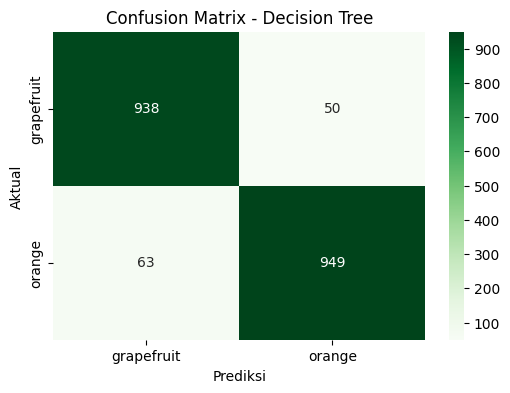

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv('citrus.csv')

# 2. Preprocessing Data
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])


X = df.drop(columns=['name'])
y = df['name']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inisialisasi dan Training Model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 4. Prediksi
y_pred_dt = dt_model.predict(X_test)

# 5. Evaluasi Hasil
print("=== EVALUASI MODEL: DECISION TREE ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

# 6. Visualisasi Confusion Matrix agar README lebih keren
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Implementasi Algoritma Naive Bayes

=== EVALUASI MODEL: NAIVE BAYES ===
Accuracy Score: 92.00%

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.91      0.93      0.92       988
      orange       0.93      0.91      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



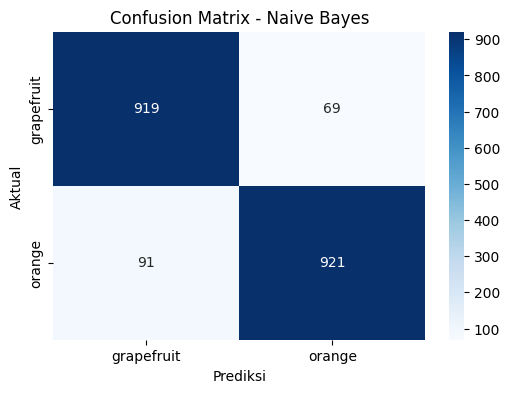

In [8]:
from sklearn.naive_bayes import GaussianNB

# 1. Inisialisasi dan Training Model Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2. Prediksi
y_pred_nb = nb_model.predict(X_test)

# 3. Evaluasi Hasil
print("=== EVALUASI MODEL: NAIVE BAYES ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

# 4. Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

Implementasi Algoritma Support Vector Machine (SVM)

=== EVALUASI MODEL: SUPPORT VECTOR MACHINE ===
Accuracy Score: 93.70%

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.93      0.95      0.94       988
      orange       0.95      0.92      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



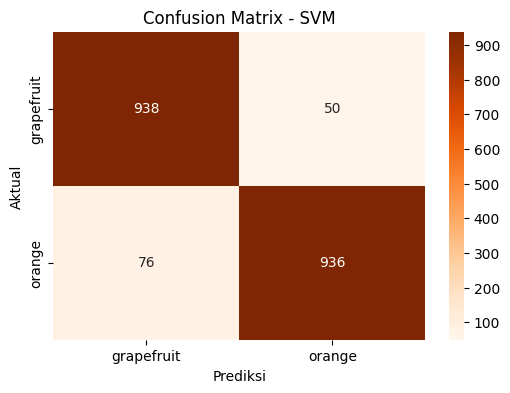

In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Feature Scaling (Krusial untuk SVM)
# Kita buat scaler baru dan terapkan pada data training & testing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inisialisasi dan Training Model SVM
# Menggunakan kernel 'rbf' (default) yang biasanya paling powerfull
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 3. Prediksi
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. Evaluasi Hasil
print("=== EVALUASI MODEL: SUPPORT VECTOR MACHINE ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - SVM')
plt.show()

Perbandingan Komprehensif & Visualisasi

=== TABEL PERBANDINGAN PERFORMA MODEL ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9435,0.943584,0.9435,0.943502
2,SVM,0.9370,0.937315,0.9370,0.936999
1,Naive Bayes,0.9200,0.920224,0.9200,0.920001


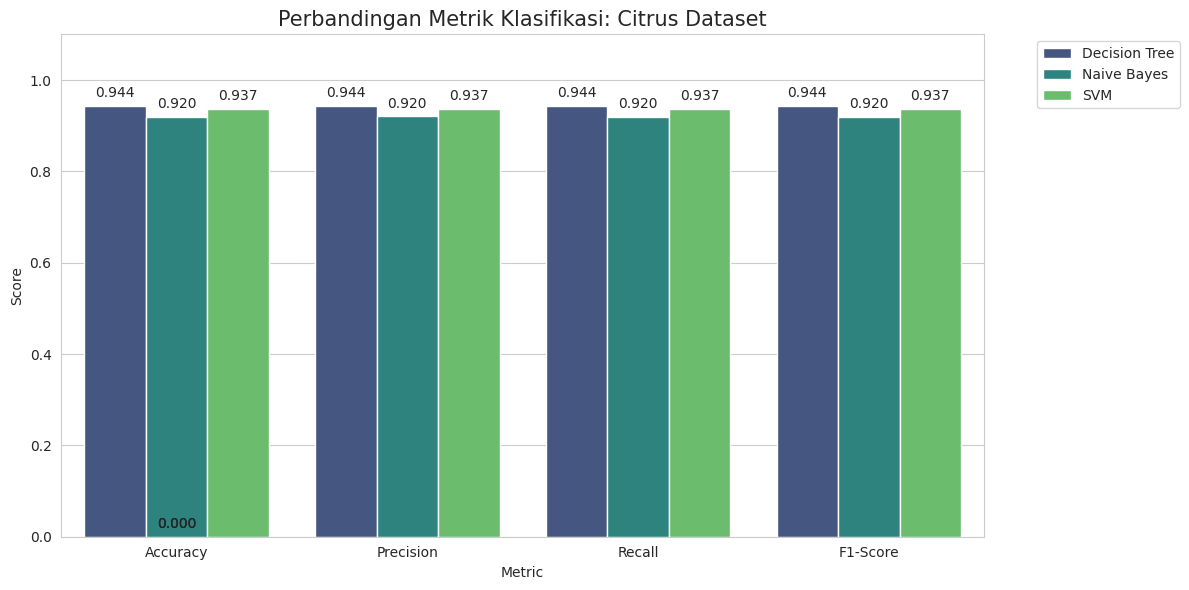

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

# 1. Menghitung Metrik Lengkap untuk Setiap Model
def get_metrics(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

comparison_data = [
    get_metrics(y_test, y_pred_dt, "Decision Tree"),
    get_metrics(y_test, y_pred_nb, "Naive Bayes"),
    get_metrics(y_test, y_pred_svm, "SVM")
]

df_compare = pd.DataFrame(comparison_data)

# 2. Menampilkan Tabel Perbandingan yang Rapi
print("=== TABEL PERBANDINGAN PERFORMA MODEL ===")
display(df_compare.sort_values(by='Accuracy', ascending=False))

# 3. Visualisasi Perbandingan dengan Bar Chart
df_melted = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.title('Perbandingan Metrik Klasifikasi: Citrus Dataset', fontsize=15)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()